In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [2]:
from pathlib import Path

ROOT = Path.cwd().parent

df = pd.read_csv(
    ROOT / "dataset" / "weather_featured.csv"
)

df.head()

,City,Temperature,Humidity,Pressure,Wind_Speed,Cloud_Cover,Weather,Rainfall,Year,Month,Day,Hour,DayOfWeek,Season
0,31,13.7,81,925.7,24.12,57,0,0.0,2011,12,25,3,3,3
1,4,27.6,86,1002.0,40.68,100,1,0.0,2023,8,5,22,2,0
2,8,27.5,90,1002.3,46.80,0,0,0.0,2018,5,21,5,1,2
3,34,16.4,46,996.7,37.08,6,0,0.0,2026,1,24,14,2,3
4,29,25.6,64,1012.8,30.96,98,1,0.0,2024,1,30,8,5,3


In [3]:
X = df.drop("Temperature", axis=1)

y = df["Temperature"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (8000, 13)
Testing : (2000, 13)


In [5]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [6]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [8]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [9]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [10]:
def evaluate_model(name, y_test, prediction):

    mae = mean_absolute_error(y_test, prediction)

    mse = mean_squared_error(y_test, prediction)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, prediction)

    print("="*50)

    print(name)

    print("="*50)

    print("MAE :", round(mae,3))

    print("MSE :", round(mse,3))

    print("RMSE:", round(rmse,3))

    print("R2 :", round(r2,3))

In [11]:
evaluate_model("Linear Regression", y_test, lr_pred)

evaluate_model("Decision Tree", y_test, dt_pred)

evaluate_model("Random Forest", y_test, rf_pred)

evaluate_model("Gradient Boosting", y_test, gb_pred)

Linear Regression
MAE : 2.918
MSE : 14.741
RMSE: 3.839
R2 : 0.531
Decision Tree
MAE : 2.006
MSE : 8.016
RMSE: 2.831
R2 : 0.745
Random Forest
MAE : 1.323
MSE : 3.673
RMSE: 1.917
R2 : 0.883
Gradient Boosting
MAE : 1.507
MSE : 4.159
RMSE: 2.039
R2 : 0.868


In [12]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "R2":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ]

})

results

,Model,R2
0,Linear Regression,0.531025
1,Decision Tree,0.744984
2,Random Forest,0.883146
3,Gradient Boosting,0.867698


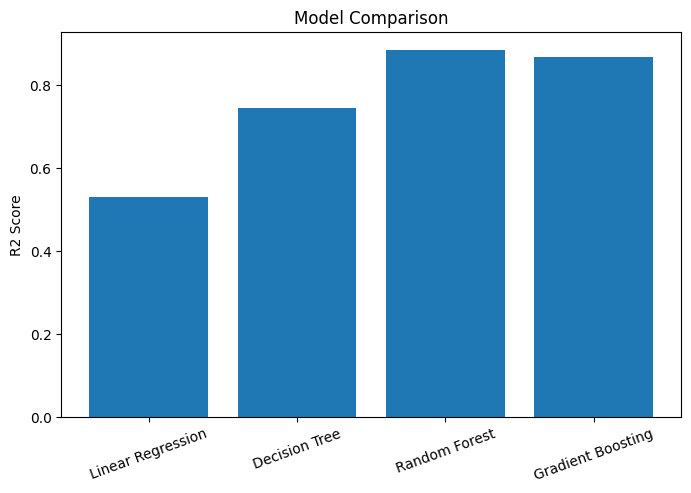

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2"])

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.xticks(rotation=20)

plt.show()

In [14]:
results.sort_values(
    by="R2",
    ascending=False
)

,Model,R2
2,Random Forest,0.883146
3,Gradient Boosting,0.867698
1,Decision Tree,0.744984
0,Linear Regression,0.531025


In [15]:
from pathlib import Path
import joblib

ROOT = Path.cwd().parent

joblib.dump(
    rf,
    ROOT / "models" / "weather_model.pkl"
)

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [16]:
from pathlib import Path
import joblib

ROOT = Path.cwd().parent

model = joblib.load(
    ROOT / "models" / "weather_model.pkl"
)

print(model)

RandomForestRegressor(random_state=42)


In [17]:
from pathlib import Path
import joblib

ROOT = Path.cwd().parent

joblib.dump(
    rf,
    ROOT / "models" / "weather_model.pkl"
)

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!
